In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

# Display settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Image

In [4]:
# Load the images
# Note: Replace 'original_image.png' and 'noisy_image.png' with your actual file names
original_image = cv2.imread('original_image.jpg', cv2.IMREAD_GRAYSCALE)
noisy_image = cv2.imread('noisy_image.jpg', cv2.IMREAD_GRAYSCALE)

if original_image is not None:
    print(f"Original image shape: {original_image.shape}")
    print(f"Noisy image shape: {noisy_image.shape}")
    print(f"Image data type: {original_image.dtype}")
    print(f"Pixel value range: [{original_image.min()}, {original_image.max()}]")
else:
    print("Please ensure the image files are in the correct directory")

Original image shape: (161, 312)
Noisy image shape: (161, 312)
Image data type: uint8
Pixel value range: [9, 255]


### Define Filter Application Function

In [5]:
def apply_filters(noisy_image, kernel_size=5):
    
    # 1. Mean Filter (Average Filter)
    mean_filtered = cv2.blur(noisy_image, (kernel_size, kernel_size))
    
    # 2. Median Filter
    # Replaces each pixel with median of neighboring pixels
    median_filtered = cv2.medianBlur(noisy_image, kernel_size)
    
    # 3. Gaussian Filter
    # Weighted average where closer pixels have higher influence
    gaussian_filtered = cv2.GaussianBlur(noisy_image, (kernel_size, kernel_size), 0)
    
    return {
        'Mean Filter': mean_filtered,
        'Median Filter': median_filtered,
        'Gaussian Filter': gaussian_filtered
    }

### Define PSNR Calculation Function

In [6]:
def calculate_psnr_custom(original, filtered):
    # Convert to float to avoid overflow
    original = original.astype(np.float64)
    filtered = filtered.astype(np.float64)
    
    # Calculate MSE (Mean Squared Error)
    mse = np.mean((original - filtered) ** 2)
    
    # Maximum possible pixel value
    max_pixel = 255.0
    
    # Calculate PSNR
    if mse == 0:
        return float('inf')
    
    psnr_value = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr_value

# Test the function with a simple example
test_psnr = calculate_psnr_custom(original_image, noisy_image)
print(f"PSNR between original and noisy image: {test_psnr:.2f} dB")
print("Lower PSNR indicates more noise/error")

PSNR between original and noisy image: 17.11 dB
Lower PSNR indicates more noise/error


### Apply all three filters with kernel size 5x5

In [10]:
kernel_size = 5
filtered_images = apply_filters(noisy_image, kernel_size)

# Calculate PSNR for each filtered image
psnr_values = {}
for filter_name, filtered_img in filtered_images.items():
    psnr_values[filter_name] = calculate_psnr_custom(original_image, filtered_img)

# Calculate PSNR between original and noisy image
psnr_noisy = calculate_psnr_custom(original_image, noisy_image)

# Display PSNR results
print("=" * 60)
print("PSNR RESULTS (Higher is better)")
print("=" * 60)
print(f"\nPSNR between original and NOISY image: {psnr_noisy:.2f} dB")
print("\nAfter filtering:")
for filter_name, psnr_val in psnr_values.items():
    print(f"  {filter_name:20s}: {psnr_val:.2f} dB")
    
# Find best filter
best_filter = max(psnr_values, key=psnr_values.get)
print(f"\n✓ Best filter based on PSNR: {best_filter}")

PSNR RESULTS (Higher is better)

PSNR between original and NOISY image: 17.11 dB

After filtering:
  Mean Filter         : 21.28 dB
  Median Filter       : 22.74 dB
  Gaussian Filter     : 22.47 dB

✓ Best filter based on PSNR: Median Filter


### Visualize Results

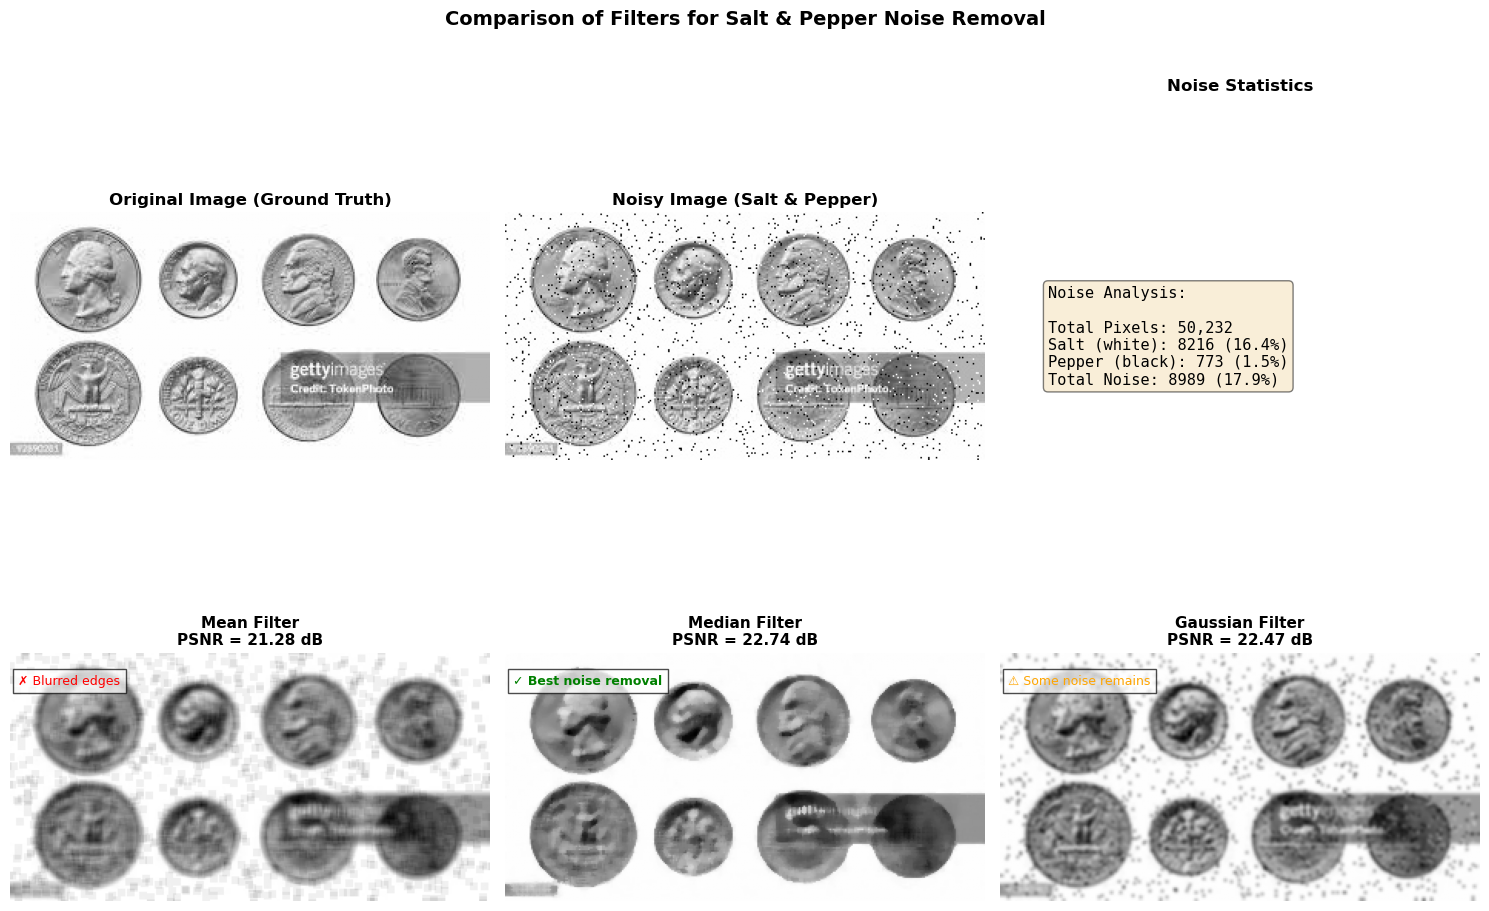

In [11]:
# Calculate noise statistics
black_pixels = np.sum(noisy_image == 0)
white_pixels = np.sum(noisy_image == 255)
total_pixels = noisy_image.size

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1, Col 1: Original Image
axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title('Original Image (Ground Truth)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Row 1, Col 2: Noisy Image
axes[0, 1].imshow(noisy_image, cmap='gray')
axes[0, 1].set_title('Noisy Image (Salt & Pepper)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Row 1, Col 3: Noise Information
noise_info = f"Noise Analysis:\n\n"
noise_info += f"Total Pixels: {total_pixels:,}\n"
noise_info += f"Salt (white): {white_pixels} ({100*white_pixels/total_pixels:.1f}%)\n"
noise_info += f"Pepper (black): {black_pixels} ({100*black_pixels/total_pixels:.1f}%)\n"
noise_info += f"Total Noise: {white_pixels+black_pixels} ({100*(white_pixels+black_pixels)/total_pixels:.1f}%)"

axes[0, 2].text(0.1, 0.5, noise_info, fontsize=11, 
                verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[0, 2].set_title('Noise Statistics', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Filtered Results
filter_names = list(filtered_images.keys())
filter_imgs = list(filtered_images.values())

for i, (img, name) in enumerate(zip(filter_imgs, filter_names)):
    axes[1, i].imshow(img, cmap='gray')
    psnr_val = psnr_values[name]
    axes[1, i].set_title(f'{name}\nPSNR = {psnr_val:.2f} dB', 
                         fontsize=11, fontweight='bold')
    axes[1, i].axis('off')
    
    # Add small text about visual quality
    if name == 'Median Filter':
        axes[1, i].text(5, 20, '✓ Best noise removal', color='green', 
                       fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
    elif name == 'Mean Filter':
        axes[1, i].text(5, 20, '✗ Blurred edges', color='red', 
                       fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    elif name == 'Gaussian Filter':
        axes[1, i].text(5, 20, '⚠ Some noise remains', color='orange', 
                       fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.suptitle('Comparison of Filters for Salt & Pepper Noise Removal', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('filtering_results.png', dpi=150, bbox_inches='tight')
plt.show()